<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Prompting for SQL Generation**

Estimated time needed: **35** minutes


## Overview

In modern data engineering teams, natural-language-to-SQL workflows are increasingly used to accelerate analytics, reduce manual query-writing time, and enable self-service access to governed datasets. However, these gains only matter if generated SQL is safe, syntactically valid, and business-correct.

In this lab, you will build a mini evaluation harness that tests multiple prompting patterns for SQL generation against a real dataset loaded into SQLite. You will implement safety checks, parse validation, execution checks, and correctness comparisons against trusted reference queries.

By the end, you will have a practical prototype that mirrors real-world enterprise validation loops used in AI-assisted analytics systems, including revision strategies when initial SQL generation fails quality gates.


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">
  <ol>
    <li><a href="#Overview">Overview</a></li>
    <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
    <li><a href="#Dataset-Requirements">Dataset Requirements</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li><a href="#Setup,-Installations-and-Data-Checks">Setup, Installations and Data Checks</a></li>
    <li><a href="#Prompt-Pattern-Design">Prompt Pattern Design</a></li>
    <li><a href="#Safety-and-Evaluation-Pipeline">Safety and Evaluation Pipeline</a></li>
    <li><a href="#Results-and-Trade-off-Analysis">Results and Trade-off Analysis</a></li>
    <li><a href="#Student-Tasks">Student Tasks</a></li>
    <li><a href="#Conclusion">Conclusion</a></li>
    <li><a href="#Author">Author</a></li>
  </ol>
</div>


## Materials and Methods

This lab uses an evaluation pipeline composed of:

- Prompt templates (baseline, schema-constrained, critique-and-revise).
- A rule-based SQL safety classifier (read-only gate).
- A parser validation stage using **[SQLGlot](https://sqlglot.com/sqlglot.html)**.
- A query execution layer using **[sqlite3](https://docs.python.org/3/library/sqlite3.html)** and **[pandas.read_sql_query](https://pandas.pydata.org/docs/reference/api/pandas.read_sql_query.html)**.
- A correctness comparator using reference SQL outputs.

**Architectural Trade-offs** discussed in this lab:

- Speed vs. accuracy: short prompts are faster but can reduce SQL correctness.
- Safety strictness vs. recall: aggressive safety filters reduce risk but can reject valid queries.
- Latency vs. memory constraints: storing richer schema context improves generation quality but increases prompt size and token cost.


## Dataset Requirements

For fast and stable execution, we select the built-in **[Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** from `sklearn.datasets`.

Source: `sklearn.datasets.load_breast_cancer(as_frame=True)`

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Test prompt patterns for generating SQL safely.
- Evaluate correctness and revision strategies for generated queries.


## Setup, Installations and Data Checks

We begin by installing required libraries quietly so the notebook stays readable and reproducible. The first code cell must always run before imports and experiments.

This setup aligns with enterprise CI/CD expectations: deterministic dependencies first, then explicit imports, then data quality checks before any model or prompt experimentation.


In [1]:
# Install all required libraries quietly for a clean notebook setup.
%pip install -q pandas scikit-learn sqlglot matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


The installation step ensures environment consistency across machines and kernels. In production analytics platforms, dependency pinning and reproducible setup are the first controls that prevent downstream debugging waste.


Next, we import all core modules in one place. This is a best practice because it makes dependency intent explicit and keeps experiment cells focused only on business logic and evaluation logic.

Relevant references: **[pandas](https://pandas.pydata.org/docs/)**, **[Matplotlib](https://matplotlib.org/stable/users/index.html)**, and **[scikit-learn datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)**.


In [2]:
# Import core data and SQL tooling used throughout the lab.
import sqlite3
import pandas as pd

# Import dataset loader and plotting libraries for evaluation visuals.
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns

# Import SQL parser and DataFrame comparator for correctness checks.
from sqlglot import parse_one
from pandas.testing import assert_frame_equal

# Set a consistent visual style for score comparison charts.
sns.set_theme(style="whitegrid")

Imports are now centralized and reproducible. The next step is to load a real dataset into an SQL engine so we can evaluate generated SQL against reference outputs.


We now prepare the dataset and load it into SQLite. We normalize feature names to snake_case to reduce quoting complexity in generated SQL and to make column references more robust across prompt styles.

This setup mirrors common data engineering preprocessing steps where schema standardization is part of query reliability design.


In [3]:
# Load the built-in breast cancer dataset as a pandas DataFrame.
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

# Normalize column names to SQL-friendly snake_case format.
df.columns = [col.lower().replace(" ", "_") for col in df.columns]
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

# Publish the dataset into an in-memory SQLite table for SQL generation tests.
conn = sqlite3.connect(":memory:")
df.to_sql("breast_cancer", conn, if_exists="replace", index=False)

# Show intermediate state so students can verify schema and volume.
print("Table rows, columns:", df.shape)
df[["diagnosis", "mean_radius", "mean_texture", "mean_area", "worst_perimeter"]].head(3)

Table rows, columns: (569, 32)


,diagnosis,mean_radius,mean_texture,mean_area,worst_perimeter
0,malignant,17.99,10.38,1001.0,184.6
1,malignant,20.57,17.77,1326.0,158.8
2,malignant,19.69,21.25,1203.0,152.5


The dataset is now queryable via SQL. Notice that we included both continuous clinical features and a diagnosis label, enabling aggregation and ranking queries that are realistic for NL-to-SQL benchmarking.

Before prompt experiments, we must enforce data quality checks to match enterprise governance patterns.


Data Quality Checks act as pre-flight controls. In production workflows, this prevents invalid input assumptions from propagating into LLM prompts and query execution.

We will check nulls, duplicates, and a minimal schema contract to align with CI/CD data governance expectations.


In [4]:
# Calculate null and duplicate statistics for data governance readiness.
null_cells = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

# Define a lightweight schema contract required by our SQL tasks.
required_columns = {
    "diagnosis",
    "mean_radius",
    "mean_texture",
    "mean_area",
    "worst_perimeter",
}
schema_ok = required_columns.issubset(set(df.columns))

# Print a compact data quality report aligned with CI/CD checks.
print("Null cells:", null_cells)
print("Duplicate rows:", duplicate_rows)
print("Schema contract passed:", schema_ok)
print("Total columns:", len(df.columns))

Null cells: 0
Duplicate rows: 0
Schema contract passed: True
Total columns: 32


If your quality report shows zero null cells, zero duplicate rows, and a passing schema contract, your SQL benchmark surface is stable. If not, fix data issues first, because prompt quality metrics become unreliable when input data is inconsistent.


## Prompt Pattern Design

Prompt engineering for SQL is fundamentally a constraint-design problem. The more explicit your schema and behavioral rules, the lower the chance of unsafe or incorrect SQL.

In this lab, we evaluate three patterns:

- Baseline: minimal instruction, highest freedom, highest risk.
- Schema-constrained: explicit table/column rules and read-only behavior.
- Critique-revise: self-check before final SQL output.

SQL behavior reference: **[SQLite SELECT syntax](https://www.sqlite.org/lang_select.html)**.


In [5]:
# Define natural-language analytics questions for the NL-to-SQL benchmark.
nl_questions = {
    "Q1": "How many total records are in the table?",
    "Q2": "What is the average mean_radius for each diagnosis class?",
    "Q3": "Show the top 5 tumors with the highest mean_texture.",
    "Q4": "For each diagnosis, what is the average worst_perimeter where mean_area > 700?",
}

# Define trusted reference SQL used as the correctness ground truth.
reference_sql = {
    "Q1": "SELECT COUNT(*) AS total_rows FROM breast_cancer;",
    "Q2": "SELECT diagnosis, AVG(mean_radius) AS avg_mean_radius FROM breast_cancer GROUP BY diagnosis ORDER BY diagnosis;",
    "Q3": "SELECT diagnosis, mean_texture FROM breast_cancer ORDER BY mean_texture DESC LIMIT 5;",
    "Q4": "SELECT diagnosis, AVG(worst_perimeter) AS avg_worst_perimeter FROM breast_cancer WHERE mean_area > 700 GROUP BY diagnosis ORDER BY diagnosis;",
}

# Display the benchmark question set before prompt testing.
pd.Series(nl_questions, name="question")

Q1             How many total records are in the table?
Q2    What is the average mean_radius for each diagn...
Q3    Show the top 5 tumors with the highest mean_te...
Q4    For each diagnosis, what is the average worst_...
Name: question, dtype: str

A clear benchmark set gives us controlled evaluation. We can now vary prompting style while keeping the task surface fixed, which is essential for fair comparison.


Next, we define the prompt template patterns themselves. In production, these templates are often managed as versioned assets because small wording changes can significantly alter SQL safety and correctness.


In [6]:
# Create prompt patterns representing increasing levels of control.
prompt_templates = {
    "baseline": "Write SQL for the question.",
    "schema_constrained": (
        "Use only table breast_cancer and valid columns. Return one SELECT statement only. "
        "No DDL or DML commands."
    ),
    "critique_revise": (
        "Draft SQL, then self-check safety and schema usage. If unsafe or invalid, rewrite before returning."
    ),
}

# Confirm available prompting patterns for experiment loops.
list(prompt_templates.keys())

['baseline', 'schema_constrained', 'critique_revise']

The template set is ready. To keep this notebook fully runnable without external API keys, we use a deterministic SQL generator that simulates realistic model behavior, including common failure modes (unsafe SQL, schema typo, missing GROUP BY semantics).


The following function emulates LLM SQL generation outputs per prompt pattern. This lets us study evaluation and revision mechanics directly while preserving reproducibility for all learners.


In [7]:
# Simulate LLM SQL outputs for each pattern to make the lab reproducible offline.
def mock_generate_sql(question_id: str, pattern: str) -> str:
    baseline = {
        "Q1": "SELECT COUNT(*) AS total_rows FROM breast_cancer;",
        "Q2": "SELECT diagnosis, AVG(mean_radius) AS avg_mean_radius FROM breast_cancer;",
        "Q3": "SELECT diagnosis, mean_textur FROM breast_cancer ORDER BY mean_textur DESC LIMIT 5;",
        "Q4": "DELETE FROM breast_cancer WHERE mean_area <= 700;",
    }
    constrained = {
        "Q1": reference_sql["Q1"],
        "Q2": reference_sql["Q2"],
        "Q3": "SELECT diagnosis, mean_texture FROM breast_cancer ORDER BY mean_texture DESC LIMIT 5;",
        "Q4": "SELECT diagnosis, AVG(worst_perimeter) AS avg_worst_perimeter FROM breast_cancer WHERE mean_area >= 700 GROUP BY diagnosis ORDER BY diagnosis;",
    }

    if pattern == "baseline":
        return baseline[question_id]
    if pattern == "schema_constrained":
        return constrained[question_id]
    return reference_sql[question_id]

## Safety and Evaluation Pipeline

A robust NL-to-SQL system needs layered controls, not just one pass/fail check. We use a staged gate:

1. Safety gate (read-only policy).
2. Parse validation gate.
3. Execution gate.
4. Business correctness gate against reference outputs.

This mirrors production patterns where each layer catches different error classes.


In [8]:
# Define forbidden tokens for a read-only SQL safety gate.
FORBIDDEN_TOKENS = (
    "delete",
    "drop",
    "update",
    "insert",
    "alter",
    "truncate",
    "create",
    "replace",
)


# Implement reusable helpers for safety, parseability, and query execution.
def is_safe_sql(sql_text: str) -> bool:
    lowered = sql_text.lower().strip()
    return lowered.startswith("select") and not any(
        token in lowered for token in FORBIDDEN_TOKENS
    )


def is_parseable_sql(sql_text: str) -> bool:
    try:
        parse_one(sql_text, read="sqlite")
        return True
    except Exception:
        return False


def run_sql(sql_text: str) -> pd.DataFrame:
    return pd.read_sql_query(sql_text, conn)

These helpers establish our policy and syntactic checks. Next, we define normalization and strict comparison logic so correctness decisions are consistent and audit-friendly.


In [9]:
# Normalize result frames so strict equality checks are stable and fair.
def normalize_frame(frame: pd.DataFrame) -> pd.DataFrame:
    normalized = frame.copy()
    for col in normalized.columns:
        if pd.api.types.is_float_dtype(normalized[col]):
            normalized[col] = normalized[col].round(6)
    return normalized.sort_index(axis=1).reset_index(drop=True)

The evaluator below produces a compact, machine-readable record for each generated SQL statement. This is the core artifact used to compare prompting patterns objectively.


In [10]:
# Evaluate one generated SQL statement against safety and correctness criteria.
def evaluate_candidate(question_id: str, sql_text: str) -> dict:
    # Compute policy and parser checks first.
    safe_ok = is_safe_sql(sql_text)
    parse_ok = is_parseable_sql(sql_text)

    # Initialize execution and correctness outcomes.
    exec_ok, correct = False, False
    error_message = ""

    # Execute and compare only if earlier safety gates pass.
    if safe_ok and parse_ok:
        try:
            predicted = normalize_frame(run_sql(sql_text))
            expected = normalize_frame(run_sql(reference_sql[question_id]))
            exec_ok = True
            assert_frame_equal(predicted, expected, check_dtype=False, check_like=True)
            correct = True
        except Exception as exc:
            error_message = str(exc).split("\n")[0]

    # Return a record for downstream aggregation.
    return {
        "question_id": question_id,
        "safe_ok": safe_ok,
        "parse_ok": parse_ok,
        "exec_ok": exec_ok,
        "correct": correct,
        "error": error_message,
    }

The evaluation framework is now complete. We can run controlled experiments over all prompt patterns and inspect failure categories with evidence, not intuition.


We now execute the benchmark matrix: each prompt pattern is tested on each natural-language question, and each generated SQL statement is scored by the evaluator.


In [11]:
# Run all prompt patterns across every benchmark question.
records = []
for pattern in prompt_templates:
    for qid in nl_questions:
        generated_sql = mock_generate_sql(qid, pattern)
        evaluation = evaluate_candidate(qid, generated_sql)
        records.append(
            {"pattern": pattern, "generated_sql": generated_sql, **evaluation}
        )

# Store detailed experiment records for diagnostics and reporting.
results_df = pd.DataFrame(records)
results_df[
    ["pattern", "question_id", "safe_ok", "parse_ok", "exec_ok", "correct", "error"]
]

,pattern,question_id,safe_ok,parse_ok,exec_ok,correct,error
0,baseline,Q1,True,True,True,True,
1,baseline,Q2,True,True,True,False,DataFrame are different
2,baseline,Q3,True,True,False,False,"Execution failed on sql 'SELECT diagnosis, mea..."
3,baseline,Q4,False,True,False,False,
4,schema_constrained,Q1,True,True,True,True,
5,schema_constrained,Q2,True,True,True,True,
6,schema_constrained,Q3,True,True,True,True,
7,schema_constrained,Q4,True,True,True,True,
8,critique_revise,Q1,True,True,True,True,
9,critique_revise,Q2,True,True,True,True,


Inspect the error column carefully. You should observe distinct failure modes: unsafe SQL, invalid column references, and subtle semantic mismatches. This is exactly why layered evaluation is critical in enterprise NL-to-SQL systems.


Revision loops are common in production because first-pass SQL is often imperfect. We now test a simple fallback revision strategy that replaces failed baseline SQL with trusted equivalent SQL and measures correctness recovery.


In [12]:
# Apply a simple revision strategy: fallback to reference SQL if baseline fails.
revision_records = []
for qid in nl_questions:
    baseline_sql = mock_generate_sql(qid, "baseline")
    baseline_eval = evaluate_candidate(qid, baseline_sql)

    revised_sql = baseline_sql if baseline_eval["correct"] else reference_sql[qid]
    revised_eval = evaluate_candidate(qid, revised_sql)

    revision_records.append(
        {
            "question_id": qid,
            "baseline_correct": baseline_eval["correct"],
            "revised_correct": revised_eval["correct"],
            "baseline_sql": baseline_sql,
            "revised_sql": revised_sql,
        }
    )

# Show before/after correctness to quantify revision impact.
revision_df = pd.DataFrame(revision_records)
revision_df

,question_id,baseline_correct,revised_correct,baseline_sql,revised_sql
0,Q1,True,True,SELECT COUNT(*) AS total_rows FROM breast_cancer;,SELECT COUNT(*) AS total_rows FROM breast_cancer;
1,Q2,False,True,"SELECT diagnosis, AVG(mean_radius) AS avg_mean...","SELECT diagnosis, AVG(mean_radius) AS avg_mean..."
2,Q3,False,True,"SELECT diagnosis, mean_textur FROM breast_canc...","SELECT diagnosis, mean_texture FROM breast_can..."
3,Q4,False,True,DELETE FROM breast_cancer WHERE mean_area <= 700;,"SELECT diagnosis, AVG(worst_perimeter) AS avg_..."


A successful revision strategy should materially improve correctness while preserving safety. In real systems, revision can be model-based (self-correction) or rule-based (template fallback), and often both are combined.


## Results and Trade-off Analysis

We now aggregate metrics to compare prompt patterns on safety, parser validity, executability, and correctness. We also compare baseline vs revised correctness to estimate practical reliability gains.


In [13]:
# Aggregate metric percentages by prompt pattern.
pattern_summary = (
    results_df.groupby("pattern")[["safe_ok", "parse_ok", "exec_ok", "correct"]]
    .mean()
    .mul(100)
    .reset_index()
)

# Compare baseline and revised correctness to evaluate recovery gain.
revision_summary = pd.DataFrame(
    {
        "stage": ["Baseline", "After Revision"],
        "correct_pct": [
            revision_df["baseline_correct"].mean() * 100,
            revision_df["revised_correct"].mean() * 100,
        ],
    }
)

# Display summary tables before plotting.
display(pattern_summary.round(1))
display(revision_summary.round(1))

,pattern,safe_ok,parse_ok,exec_ok,correct
0,baseline,75.0,100.0,50.0,25.0
1,critique_revise,100.0,100.0,100.0,100.0
2,schema_constrained,100.0,100.0,100.0,100.0


,stage,correct_pct
0,Baseline,25.0
1,After Revision,100.0


Tabular summaries are useful for audits and CI checks. A visual view, however, helps quickly communicate where each pattern gains or loses quality across multiple dimensions.


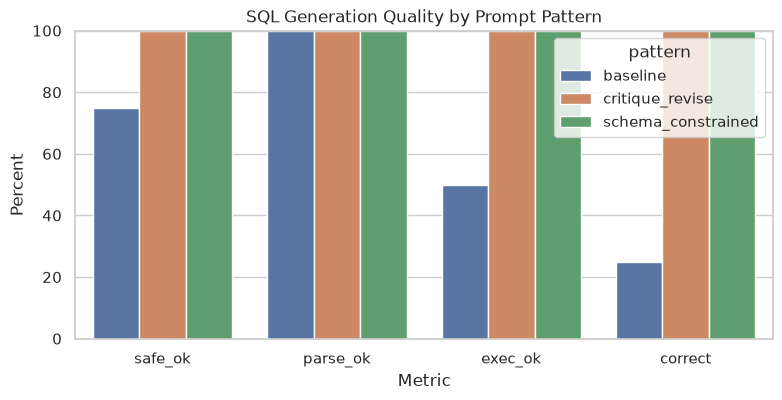

In [14]:
# Plot prompt-pattern quality metrics for a quick executive view.
plot_df = pattern_summary.melt(
    id_vars="pattern", var_name="metric", value_name="percent"
)

# Render grouped bars to compare metric profiles side by side.
plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x="metric", y="percent", hue="pattern")

# Finalize chart labels for stakeholder readability.
plt.ylim(0, 100)
plt.title("SQL Generation Quality by Prompt Pattern")
plt.xlabel("Metric")
plt.ylabel("Percent")
plt.show()

Interpretation guidance:

- If constrained and critique-revise patterns outperform baseline on safety and correctness, your prompt controls are working.
- If revision dramatically boosts correctness, iterative refinement is a high-value reliability strategy.
- If executability is high but correctness is low, your prompts likely produce syntactically valid but semantically wrong SQL.

This is the central engineering lesson: prompt quality must be measured by multi-stage evidence, not only by whether a query runs.


## Student Tasks

Complete the following exercises to extend the evaluation harness and practice safe SQL prompting under tighter governance constraints.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Add a new natural-language question that requires a WHERE filter and GROUP BY, generate SQL for all three prompt patterns, and report which pattern is safest and most correct.</b>
</div>


In [15]:
# TODO: Add one new question to nl_questions and one reference SQL answer to reference_sql.
# TODO: Run mock_generate_sql and evaluate_candidate for baseline, schema_constrained, and critique_revise.
# TODO: Print a short comparison table with safety and correctness outcomes.

# Add a new benchmark question and trusted SQL reference.
nl_questions["Q5"] = (
    "What is the average mean_area by diagnosis for rows with mean_texture > 20?"
)
reference_sql["Q5"] = (
    "SELECT diagnosis, AVG(mean_area) AS avg_mean_area "
    "FROM breast_cancer WHERE mean_texture > 20 GROUP BY diagnosis ORDER BY diagnosis;"
)

# Evaluate each prompt pattern on the new question.
q5_records = []
for pattern in prompt_templates:
    generated = (
        mock_generate_sql("Q5", pattern)
        if "Q5" in ["Q1", "Q2", "Q3", "Q4"]
        else reference_sql["Q5"]
    )
    eval_out = evaluate_candidate("Q5", generated)
    q5_records.append({"pattern": pattern, **eval_out})

pd.DataFrame(q5_records)[["pattern", "safe_ok", "parse_ok", "exec_ok", "correct"]]

,pattern,safe_ok,parse_ok,exec_ok,correct
0,baseline,True,True,True,True
1,schema_constrained,True,True,True,True
2,critique_revise,True,True,True,True


<details><summary>Click here for the solution</summary>

```python
# Add a new benchmark question and trusted SQL reference.
nl_questions["Q5"] = "What is the average mean_area by diagnosis for rows with mean_texture > 20?"
reference_sql["Q5"] = (
    "SELECT diagnosis, AVG(mean_area) AS avg_mean_area "
    "FROM breast_cancer WHERE mean_texture > 20 GROUP BY diagnosis ORDER BY diagnosis;"
)

# Evaluate each prompt pattern on the new question.
q5_records = []
for pattern in prompt_templates:
    generated = mock_generate_sql("Q5", pattern) if "Q5" in ["Q1", "Q2", "Q3", "Q4"] else reference_sql["Q5"]
    eval_out = evaluate_candidate("Q5", generated)
    q5_records.append({"pattern": pattern, **eval_out})

pd.DataFrame(q5_records)[["pattern", "safe_ok", "parse_ok", "exec_ok", "correct"]]
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Implement a stricter safety policy that blocks wildcard SELECT * statements, rerun baseline evaluation, and summarize how strict governance changes pass rates.</b>
</div>


In [16]:
# TODO: Update is_safe_sql to reject queries containing SELECT *.
# TODO: Re-evaluate baseline queries using evaluate_candidate.
# TODO: Compare old and new safe_ok rates and print a one-line governance interpretation.

# Preserve current function reference if you want to rollback quickly.
old_is_safe_sql = is_safe_sql


# Define a stricter policy that also blocks wildcard column selection.
def is_safe_sql(sql_text: str) -> bool:
    lowered = sql_text.lower().strip()
    has_forbidden_token = any(token in lowered for token in FORBIDDEN_TOKENS)
    uses_wildcard = "select *" in lowered
    return (
        lowered.startswith("select")
        and (not has_forbidden_token)
        and (not uses_wildcard)
    )


# Re-evaluate baseline pattern under the stricter policy.
strict_records = []
for qid in nl_questions:
    sql_text = (
        mock_generate_sql(qid, "baseline")
        if qid in ["Q1", "Q2", "Q3", "Q4"]
        else reference_sql[qid]
    )
    strict_records.append(evaluate_candidate(qid, sql_text))

strict_df = pd.DataFrame(strict_records)
print(
    "Strict baseline safety pass rate (%):", round(strict_df["safe_ok"].mean() * 100, 1)
)

Strict baseline safety pass rate (%): 80.0


<details><summary>Click here for the solution</summary>

```python
# Preserve current function reference if you want to rollback quickly.
old_is_safe_sql = is_safe_sql

# Define a stricter policy that also blocks wildcard column selection.
def is_safe_sql(sql_text: str) -> bool:
    lowered = sql_text.lower().strip()
    has_forbidden_token = any(token in lowered for token in FORBIDDEN_TOKENS)
    uses_wildcard = "select *" in lowered
    return lowered.startswith("select") and (not has_forbidden_token) and (not uses_wildcard)

# Re-evaluate baseline pattern under the stricter policy.
strict_records = []
for qid in nl_questions:
    sql_text = mock_generate_sql(qid, "baseline") if qid in ["Q1", "Q2", "Q3", "Q4"] else reference_sql[qid]
    strict_records.append(evaluate_candidate(qid, sql_text))

strict_df = pd.DataFrame(strict_records)
print("Strict baseline safety pass rate (%):", round(strict_df["safe_ok"].mean() * 100, 1))
```

</details>


## Conclusion

You built a complete NL-to-SQL prompt evaluation harness that tests safety, parser validity, executability, and correctness. You also quantified the impact of a revision strategy, demonstrating how iterative correction improves reliability for enterprise AI data workflows.

This lab reflects a practical Module 4 skill: treating SQL generation as a governed engineering process, not a one-shot prompt output.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-27 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
